# Imports

In [13]:
import sys
from pathlib import Path
import pandas as pd
import fitz  
import tiktoken
from pathlib import Path
from openai import OpenAI
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..").resolve()))


from system.rag import (
    LLM,
    Approaches,
    RAGExperimentRunner,
    CSVProcessor,
    LangfairMetricsCalculator,
    LangfairRunner,
    ApproachRetrievers,
)

from system.preprocess import (
    PDFPreprocessConfig,
    PDFPreprocessor,
    CorpusBuilderConfig,
    CorpusBuilder,
)


from system.evaluation import (
    JudgeBatchConfig,
    JudgeBatchBuilder,
    BatchResultsConfig,
    BatchResultsExporter,
    JudgeMergeConfig,
    JudgeResultsMerger,
    CSVColumnMergeConfig, 
    CSVColumnMerger
)

# Check if Tokens will fit in the context window

## CROP PDFS

In [14]:
PDF_DIR = Path("../data/input/input_pdfs")

TARGETS = {
    "Mill (Bridgeport)": {
        "path": PDF_DIR / "Bridgeport Series 1 Milling manual with schematics.pdf",
        "crop_top": 0.04, "crop_bottom": 0.075, "crop_left": 0.0, "crop_right": 0.0, # different crop percents for this manual to remove headers and footers
    },
    "UR5e Cobot": {
        "path": PDF_DIR / "UR5e_Universal_Robots User Manual.pdf",
        "crop_percent": 0.075,
    },
}

In [15]:
from langchain_community.document_loaders import PyMuPDFLoader

def load_pdf_as_text(path) -> str:
    pages = PyMuPDFLoader(str(path)).load()
    return "\n\n".join(p.page_content for p in pages).strip()

mill_text = load_pdf_as_text(TARGETS["Mill (Bridgeport)"]["path"])
ur5e_text = load_pdf_as_text(TARGETS["UR5e Cobot"]["path"])

print(f"Mill  : {len(mill_text):,} chars")
print(f"UR5e  : {len(ur5e_text):,} chars")

Mill  : 123,442 chars
UR5e  : 276,138 chars


In [16]:
doc = fitz.open(TARGETS["UR5e Cobot"]["path"])

### Crop PDFs and extract text

In [17]:
OUTPUT_DIR = Path("../data/input/cropped_pdfs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CROPPED = {}
for label, cfg in TARGETS.items():
    out = OUTPUT_DIR / f"cropped_{cfg['path'].name}"
    PDFPreprocessor.crop_pdf(
        cfg["path"], out,
        crop_percent=cfg.get("crop_percent", 0.075),
        crop_top=cfg.get("crop_top"),
        crop_bottom=cfg.get("crop_bottom"),
        crop_left=cfg.get("crop_left"),
        crop_right=cfg.get("crop_right"),
    )
    CROPPED[label] = out
    print(f"Cropped {label} -> {out.name}")

Cropped Mill (Bridgeport) -> cropped_Bridgeport Series 1 Milling manual with schematics.pdf
Cropped UR5e Cobot -> cropped_UR5e_Universal_Robots User Manual.pdf


In [18]:
mill_cropped_text = load_pdf_as_text(CROPPED["Mill (Bridgeport)"])
ur5e_cropped_text = load_pdf_as_text(CROPPED["UR5e Cobot"])

print(f"Mill  (cropped): {len(mill_cropped_text):,} chars")
print(f"UR5e  (cropped): {len(ur5e_cropped_text):,} chars")

Mill  (cropped): 121,502 chars
UR5e  (cropped): 253,244 chars


In [19]:
enc = tiktoken.get_encoding("cl100k_base")

for label, cfg in TARGETS.items():
    orig = load_pdf_as_text(cfg["path"])
    cropped = load_pdf_as_text(CROPPED[label])
    orig_tokens = len(enc.encode(orig))
    crop_tokens = len(enc.encode(cropped))
    print(f"{label}")
    print(f"  Original : {orig_tokens:,} tokens")
    print(f"  Cropped  : {crop_tokens:,} tokens")
    print(f"  Diff     : {orig_tokens - crop_tokens:,} tokens removed")
    print()

Mill (Bridgeport)
  Original : 46,606 tokens
  Cropped  : 45,319 tokens
  Diff     : 1,287 tokens removed

UR5e Cobot
  Original : 68,416 tokens
  Cropped  : 60,754 tokens
  Diff     : 7,662 tokens removed



# Long-Context RAG Evaluation

In [20]:
print(ur5e_cropped_text[:100])

riginal instructions (en)
PolyScope 5
User Manual
UR5e



The information contained herein is the pr


In [21]:
from system.utils import EnvironmentConfig, read_text

env_config = EnvironmentConfig()
rets = ApproachRetrievers(env_config)
rets.set_long_context_texts({
    "Mill (Bridgeport)": mill_cropped_text,
    "UR5e Cobot": ur5e_cropped_text,
})

## Run Experiment — Mill

In [22]:
runner = RAGExperimentRunner(
    retrievers=rets,
    num_replicates=1,
    approaches=Approaches.LONG_CONTEXT,
    models=LLM.GPT_5_MINI_2025_08_07 | LLM.GPT_5_NANO_2025_08_07 | LLM.GPT_5_4_2025_08_07 | LLM.CLAUDE_OPUS_4_6,
    max_tokens_list=[5000],
    efforts=["low"],
    topk_list=[1],
    ans_instr_A=read_text("../data/prompts/ans_instr_A.txt"),
    fewshot_A=read_text("../data/prompts/fewshot_A.txt"),
    max_concurrent=5,
    max_chars_per_content=500_000,
    include_hits_text= False
)
print(runner)

RAGExperimentRunner Configuration
  Approaches       : ['long_context']
  Models           : ['gpt-5-mini-2025-08-07', 'gpt-5-nano-2025-08-07', 'gpt-5.4-2026-03-05', 'claude-opus-4-6']
  Max tokens       : [5000]
  Efforts          : ['low']
  Top-k            : [1]
  Answer instr IDs : ['A']
  Few-shot IDs     : ['A']
  Replicates       : 1
  Max concurrent   : 5
  Max chars/content: 500,000
  Include hits text: False
  Min words subsplit: 3000


In [11]:
MILL_QA_test= Path("../data/QA/MILL/Mill Feedback Accepted_test.csv")
MILL_QA = Path("../data/QA/MILL/Mill Feedback Accepted.csv")
MILL_OUTPUT = Path("../data/results/RAG_Output/LongContext/MILL_LONG_CONTEXT_OUTPUT.csv")
df = pd.read_csv(MILL_QA)
print(df.shape)


(51, 2)


In [40]:
await runner.run(MILL_QA, MILL_OUTPUT)

RAGExperimentRunner Configuration
  Approaches       : ['long_context']
  Models           : ['gpt-5-mini-2025-08-07', 'gpt-5-nano-2025-08-07', 'gpt-5.4-2026-03-05', 'claude-opus-4-6']
  Max tokens       : [5000]
  Efforts          : ['low']
  Top-k            : [1]
  Answer instr IDs : ['A']
  Few-shot IDs     : ['A']
  Replicates       : 1
  Max concurrent   : 5
  Max chars/content: 500,000
  Include hits text: False
  Min words subsplit: 3000
----------------------------------------
  Questions        : 51
  Total permutations: 204
Completed 5 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 10 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 15 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 20 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 25 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 30 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 35 runs for 

[{'permutation_id': 'eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2lkIjoiQSIsImFwcHJvYWNoIjoibG9uZ19jb250ZXh0IiwiZWZmb3J0IjoibG93IiwiZmV3X3Nob3RfaWQiOiJBIiwibWF4X3Rva2VucyI6NTAwMCwibW9kZWwiOiJjbGF1ZGUtb3B1cy00LTYiLCJyZWFzb25pbmdfZWZmb3J0IjoibG93IiwidG9wX2siOjF9LCJydW5fdXVpZCI6IjBlY2RlNzcwLTAxMGUtNDgwMC05MmEyLTQ1ZjdlZmI0N2I0NSJ9HymzXzypicY',
  'time_started': '2026-03-16 19:39:28 EDT',
  'time_ended': '2026-03-16 19:39:41 EDT',
  'total_elapsed_time': '13.55 Seconds',
  'min_words_for_subsplit': 3000,
  'approach': 'long_context',
  'model': 'claude-opus-4-6',
  'max_tokens': 5000,
  'reasoning_effort': 'low',
  'top_k': 1,
  'answer_instructions_id': 'A',
  'few_shot_id': 'A',
  'replicate': 1,
  'question': 'How do I set the maximum depth for the bridgeport mill?',
  'gold_answer': 'Use the micrometer nut along with the quill stop. Each graduation on th enut indicates .001 inches of depth, and can be read directly to the scale mounted along the side of it.',
  'generated_answer': '# S

## Run Experiment — UR5e

In [23]:
UR5E_QA = Path("../data/QA/COBOT/Final_COBOT_QA.csv")  
UR5E_QA_test = Path("../data/QA/COBOT/Final_COBOT_QA_test.csv")
UR5E_OUTPUT = Path("../data/results/RAG_Output/LongContext/UR5E_LONG_CONTEXT_OUTPUT.csv")
print(UR5E_QA_test.exists() & UR5E_QA.exists() & UR5E_OUTPUT.parent.exists())
df = pd.read_csv(UR5E_QA)
print(df.shape)

True
(60, 2)


In [24]:
await runner.run(UR5E_QA, UR5E_OUTPUT)

RAGExperimentRunner Configuration
  Approaches       : ['long_context']
  Models           : ['gpt-5-mini-2025-08-07', 'gpt-5-nano-2025-08-07', 'gpt-5.4-2026-03-05', 'claude-opus-4-6']
  Max tokens       : [5000]
  Efforts          : ['low']
  Top-k            : [1]
  Answer instr IDs : ['A']
  Few-shot IDs     : ['A']
  Replicates       : 1
  Max concurrent   : 5
  Max chars/content: 500,000
  Include hits text: False
  Min words subsplit: 3000
----------------------------------------
  Questions        : 60
  Total permutations: 240
Completed 5 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 10 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 15 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 20 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 25 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 30 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 35 runs for 

[{'permutation_id': 'eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2lkIjoiQSIsImFwcHJvYWNoIjoibG9uZ19jb250ZXh0IiwiZWZmb3J0IjoibG93IiwiZmV3X3Nob3RfaWQiOiJBIiwibWF4X3Rva2VucyI6NTAwMCwibW9kZWwiOiJjbGF1ZGUtb3B1cy00LTYiLCJyZWFzb25pbmdfZWZmb3J0IjoibG93IiwidG9wX2siOjF9LCJydW5fdXVpZCI6ImQ0ZDg3NjA5LTk4NzMtNDhhYS04YjYxLWU1OWQyOTRhMTE2YSJ9g7bvK6H4M0k',
  'time_started': '2026-03-17 19:49:25 EDT',
  'time_ended': '2026-03-17 19:49:34 EDT',
  'total_elapsed_time': '9.58 Seconds',
  'min_words_for_subsplit': 3000,
  'approach': 'long_context',
  'model': 'claude-opus-4-6',
  'max_tokens': 5000,
  'reasoning_effort': 'low',
  'top_k': 1,
  'answer_instructions_id': 'A',
  'few_shot_id': 'A',
  'replicate': 1,
  'question': 'What should I do to avoid a pinching hazard?',
  'gold_answer': 'Remove obstacles in the area around the robot. Set up stricter safety planes and joint limits, and check the recommended special needs for your robot arm. ',
  'generated_answer': 'To avoid pinching hazards on the UR5

In [53]:
df = pd.read_csv(UR5E_OUTPUT)
num_missing = df.groupby("meta_model").size().iloc[1] - df.groupby("meta_model").size().iloc[2]

In [54]:
qa_df = pd.read_csv(UR5E_QA)
qa_df.tail(num_missing)

,question,gold_answer
13,Can I use bleach as a cleaning agent? What sho...,You should not use bleach as a cleaning soluti...
14,I got some grease on my arm while cleaning. Is...,"No, grease is an irritant and can cause an all..."
15,NaN,NaN
16,I dropped some liquid on my robot arm. Will th...,It has the potential for a break or safety iss...
17,NaN,NaN
18,What does the symbol with 3 arrowed lines emer...,This is a icon used for the translation contro...
19,What should I do to avoid a pinching hazard?,Remove obstacles in the area around the robot....
20,How much space do I need to leave around the c...,"For the UR5e model, the minimum clearance is 5..."
21,NaN,NaN
22,NaN,NaN


In [14]:
SYNTHETIC_QA = Path("../data/QA/synthetic_qa_cobot_mill.csv")
SYNTHETIC_OUTPUT = Path("../data/results/RAG_Output/LongContext/SYNTHETIC_LONG_CONTEXT_OUTPUT.csv")

# df = pd.read_csv(SYNTHETIC_QA)
# df.head(1).to_csv(SYNTHETIC_QA.parent / "synthetic_qa_cobot_mill_test.csv", index=False)
SYNTHETIC_QA_test = SYNTHETIC_QA.parent / "synthetic_qa_cobot_mill_test.csv"
df = pd.read_csv(SYNTHETIC_QA)
print(df.shape)

(100, 3)


In [15]:
await runner.run(SYNTHETIC_QA, SYNTHETIC_OUTPUT)

RAGExperimentRunner Configuration
  Approaches       : ['long_context']
  Models           : ['gpt-5-mini-2025-08-07', 'gpt-5-nano-2025-08-07', 'gpt-5.4-2026-03-05', 'claude-opus-4-6']
  Max tokens       : [5000]
  Efforts          : ['low']
  Top-k            : [1]
  Answer instr IDs : ['A']
  Few-shot IDs     : ['A']
  Replicates       : 1
  Max concurrent   : 5
  Max chars/content: 500,000
  Include hits text: False
  Min words subsplit: 3000
----------------------------------------
  Questions        : 100
  Total permutations: 400
Completed 5 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 10 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 15 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 20 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 25 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 30 runs for approach=long_context, model=gpt-5-mini-2025-08-07
Completed 35 runs for

/Users/ryan/Desktop/Work/SIGHT/safety_rag_eval_ryan/venv/lib/python3.10/site-packages/pygments/regexopt.py:77: RuntimeWarning: coroutine 'RAGExperimentRunner.run.<locals>.process_one' was never awaited
  '|'.join(regex_opt_inner(list(group[1]), '')


RateLimitError: Error code: 429 - {'type': 'error', 'error': {'type': 'rate_limit_error', 'message': "This request would exceed your organization's rate limit of 2,000,000 input tokens per minute (org: b1f4ac5c-d2e0-404d-aab3-12592ac401a5, model: claude-opus-4-6). For details, refer to: https://docs.claude.com/en/api/rate-limits. You can see the response headers for current usage. Please reduce the prompt length or the maximum tokens requested, or try again later. You may also contact sales at https://claude.com/contact-sales to discuss your options for a rate limit increase."}, 'request_id': 'req_011CZ7oruvj8PsBqtxG4nyqX'}

In [30]:
df = pd.read_csv(SYNTHETIC_OUTPUT)
df.tail()

,permutation_id,time_started,time_ended,total_elapsed_time,min_words_for_subsplit,approach,model,max_tokens,reasoning_effort,top_k,...,generated_answer,retrieved_files,meta_resp_id,meta_model,meta_status,meta_created,meta_input_tokens,meta_output_tokens,meta_total_tokens,meta_reason
380,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-03-16 21:46:24 EDT,2026-03-16 21:46:37 EDT,12.63 Seconds,3000,long_context,claude-opus-4-6,5000,low,1,...,"According to both ANSI B11.8-1983, Section 5.1...",Mill (Bridgeport);UR5e Cobot,msg_0134YmYsr4dJLKXKrxuHRveH,claude-opus-4-6,end_turn,NaN,118409,162,118571,NaN
381,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-03-16 21:46:24 EDT,2026-03-16 21:46:33 EDT,8.64 Seconds,3000,long_context,claude-opus-4-6,5000,low,1,...,If you notice unusual noise or vibration durin...,Mill (Bridgeport);UR5e Cobot,msg_0152JpY8WRWAoQAzuqpPbhgR,claude-opus-4-6,end_turn,NaN,118407,104,118511,NaN
382,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-03-16 21:46:24 EDT,2026-03-16 21:46:30 EDT,5.91 Seconds,3000,long_context,claude-opus-4-6,5000,low,1,...,"When replacing metering units, you must ensure...",Mill (Bridgeport);UR5e Cobot,msg_01K128c2UCcJ6hzE6uhSGrAJ,claude-opus-4-6,end_turn,NaN,118403,40,118443,NaN
383,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-03-16 21:46:24 EDT,2026-03-16 21:46:31 EDT,6.54 Seconds,3000,long_context,claude-opus-4-6,5000,low,1,...,Based on the 8F Power Feed Circuit Board parts...,Mill (Bridgeport);UR5e Cobot,msg_017R66BZ2apVksXSgZ5keXEp,claude-opus-4-6,end_turn,NaN,118412,81,118493,NaN
384,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-03-16 21:46:24 EDT,2026-03-16 21:46:32 EDT,7.15 Seconds,3000,long_context,claude-opus-4-6,5000,low,1,...,No. The 6F Power Feed Field Conversion Kits fo...,Mill (Bridgeport);UR5e Cobot,msg_0189Lhr8UBSdJmU352nYDjL5,claude-opus-4-6,end_turn,NaN,118409,63,118472,NaN


In [33]:
df.groupby("meta_model").size()

meta_model
claude-opus-4-6           85
gpt-5-mini-2025-08-07    100
gpt-5-nano-2025-08-07    100
gpt-5.4-2026-03-05       100
dtype: int64

In [34]:
df = pd.read_csv(SYNTHETIC_QA).tail(15)
df

,machine,question,gold_answer
85,Bridgeport Mill,What should you do if the Bridgeport mill show...,Do not operate the equipment. Report any exces...
86,Bridgeport Mill,What personal items or clothing are specifical...,"Do not wear rings, watches, jewelry, loose clo..."
87,Bridgeport Mill,"When cleaning the machine after uncrating, wha...",Do not use gasoline or any other flammable cle...
88,Bridgeport Mill,"Before moving the table, saddle, knee, or any ...",All ways must be well cleaned and lubricated b...
89,Bridgeport Mill,Which chemicals in coolants or cutting oils ca...,"Mono-ethanolamine, Di-ethanolamine, Tri-ethano..."
90,Bridgeport Mill,What information must be provided when orderin...,Provide the complete machine serial number fro...
91,Bridgeport Mill,What should be done if the spindle brake is wo...,"When the spindle brake is worn out, it must be..."
92,Bridgeport Mill,How is spindle speed changed within the select...,"Start the spindle first, then turn handwheel “..."
93,Bridgeport Mill,What are the steps for engaging automatic quil...,1. Ensure quill lock “G” is off.\n2. Set micro...
94,Bridgeport Mill,What feed rates can be selected with the quill...,"The quill feed selector provides .0015"", .003""..."


In [36]:
df.to_csv(SYNTHETIC_QA.parent / "synthetic_qa_cobot_mill_tail.csv", index=False)
SYNTHETIC_QA_TAIL = SYNTHETIC_QA.parent / "synthetic_qa_cobot_mill_tail.csv"

In [35]:
runner_last5_synth = RAGExperimentRunner(
    retrievers=rets,
    num_replicates=1,
    approaches=Approaches.LONG_CONTEXT,
    models= LLM.CLAUDE_OPUS_4_6,
    max_tokens_list=[5000],
    efforts=["low"],
    topk_list=[1],
    ans_instr_A=read_text("../data/prompts/ans_instr_A.txt"),
    fewshot_A=read_text("../data/prompts/fewshot_A.txt"),
    max_concurrent=5,
    max_chars_per_content=500_000,
    include_hits_text= False
)
print(runner_last5_synth)

RAGExperimentRunner Configuration
  Approaches       : ['long_context']
  Models           : ['claude-opus-4-6']
  Max tokens       : [5000]
  Efforts          : ['low']
  Top-k            : [1]
  Answer instr IDs : ['A']
  Few-shot IDs     : ['A']
  Replicates       : 1
  Max concurrent   : 5
  Max chars/content: 500,000
  Include hits text: False
  Min words subsplit: 3000


In [37]:
await runner_last5_synth.run(SYNTHETIC_QA_TAIL, SYNTHETIC_OUTPUT)

RAGExperimentRunner Configuration
  Approaches       : ['long_context']
  Models           : ['claude-opus-4-6']
  Max tokens       : [5000]
  Efforts          : ['low']
  Top-k            : [1]
  Answer instr IDs : ['A']
  Few-shot IDs     : ['A']
  Replicates       : 1
  Max concurrent   : 5
  Max chars/content: 500,000
  Include hits text: False
  Min words subsplit: 3000
----------------------------------------
  Questions        : 15
  Total permutations: 15
Completed 5 runs for approach=long_context, model=claude-opus-4-6
Completed 10 runs for approach=long_context, model=claude-opus-4-6
Completed 15 runs for approach=long_context, model=claude-opus-4-6
All results written to ../data/results/RAG_Output/LongContext/SYNTHETIC_LONG_CONTEXT_OUTPUT.csv


[{'permutation_id': 'eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2lkIjoiQSIsImFwcHJvYWNoIjoibG9uZ19jb250ZXh0IiwiZWZmb3J0IjoibG93IiwiZmV3X3Nob3RfaWQiOiJBIiwibWF4X3Rva2VucyI6NTAwMCwibW9kZWwiOiJjbGF1ZGUtb3B1cy00LTYiLCJyZWFzb25pbmdfZWZmb3J0IjoibG93IiwidG9wX2siOjF9LCJydW5fdXVpZCI6IjBiNWJmYTg3LTlhZTYtNDFhYy1hOWI0LTZjNjU3ZTJlYjhkNSJ9GmhIQhoS8C8',
  'time_started': '2026-03-16 21:57:11 EDT',
  'time_ended': '2026-03-16 21:57:17 EDT',
  'total_elapsed_time': '6.21 Seconds',
  'min_words_for_subsplit': 3000,
  'approach': 'long_context',
  'model': 'claude-opus-4-6',
  'max_tokens': 5000,
  'reasoning_effort': 'low',
  'top_k': 1,
  'answer_instructions_id': 'A',
  'few_shot_id': 'A',
  'replicate': 1,
  'question': 'When doing heavy milling work on the Bridgeport mill, where should the head be positioned for maximum rigidity?',
  'gold_answer': 'Keep the head as close to the column as possible. The manual states this gives maximum rigidity on heavy milling work.',
  'generated_answer': 'When d

In [56]:
df = pd.read_csv(SYNTHETIC_OUTPUT)
print(df.shape)

(400, 25)


# Compute Similarity Metrics

In [25]:
metrics_runner = LangfairRunner(
    calculator=LangfairMetricsCalculator(),
    processor=CSVProcessor(),
    max_concurrent=500,
)
# await metrics_runner.run(q_a_csv=MILL_OUTPUT, out_csv=None)
await metrics_runner.run(q_a_csv=UR5E_OUTPUT, out_csv=None)
# await metrics_runner.run(q_a_csv=SYNTHETIC_OUTPUT, out_csv=None)

Total rows to process: 240
Saved results → /Users/ryan/Desktop/Work/SIGHT/safety_rag_eval_ryan/data/results/RAG_Output/LongContext/UR5E_LONG_CONTEXT_OUTPUT_with_metrics.csv


PosixPath('../data/results/RAG_Output/LongContext/UR5E_LONG_CONTEXT_OUTPUT_with_metrics.csv')

# Judge Batch (Helpfulness & Correctness)

In [27]:
# judge_config = JudgeBatchConfig(
#     csv_path=MILL_OUTPUT,
#     output_jsonl=Path("../data/results/batchprocess/BatchJsonLongContext/MILL_LONG_CONTEXT_BATCH.jsonl"),
#     judge_model="gpt-5",
#     completion_window="24h",
#     submit_to_openai=True,  # set True when ready
#     env_file=None,
# )
# builder = JudgeBatchBuilder(judge_config)
# result = builder.run()
# print(f"Prepared {result['num_requests']} requests (submitted={result['submitted']})")

judge_config_ur5e = JudgeBatchConfig(
    csv_path=UR5E_OUTPUT,
    output_jsonl=Path("../data/results/batchprocess/BatchJsonLongContext/UR5E_LONG_CONTEXT_BATCH.jsonl"),
    judge_model="gpt-5",    
    completion_window="24h",
    submit_to_openai=True,  # set True when ready
    env_file=None,
)
builder_ur5e = JudgeBatchBuilder(judge_config_ur5e)
result_ur5e = builder_ur5e.run()
print(f"Prepared {result_ur5e['num_requests']} requests (submitted={result_ur5e['submitted']})")

# judge_config_synthetic = JudgeBatchConfig(
#     csv_path=SYNTHETIC_OUTPUT,
#     output_jsonl=Path("../data/results/batchprocess/BatchJsonLongContext/SYNTHETIC_LONG_CONTEXT_BATCH.jsonl"),
#     judge_model="gpt-5",
#     completion_window="24h",
#     submit_to_openai=True,  # set True when ready
#     env_file=None,
# )
# builder_synthetic = JudgeBatchBuilder(judge_config_synthetic)
# result_synthetic = builder_synthetic.run()
# print(f"Prepared {result_synthetic['num_requests']} requests (submitted={result_synthetic['submitted']})")

batch_69b9eb0f18b48190b07e1853c712f27b
Prepared 480 requests (submitted=True)


In [28]:
batch_id = {
            "UR5E_LONG_CONTEXT_BATCH": result_ur5e["submission"]["batch_id"],
            }
batch_id

{'UR5E_LONG_CONTEXT_BATCH': 'batch_69b9eb0f18b48190b07e1853c712f27b'}

In [61]:
batch_id = {"MILL_LONG_CONTEXT_BATCH": result["submission"]["batch_id"],
            "SYNTHETIC_LONG_CONTEXT_BATCH": result_synthetic["submission"]["batch_id"]}
batch_id

{'MILL_LONG_CONTEXT_BATCH': 'batch_69b8bbc846748190b2cc964c9ff7b77a',
 'SYNTHETIC_LONG_CONTEXT_BATCH': 'batch_69b8bbcb42b881909917ef6bd6075670'}

In [29]:
import json

batch_ids_path = Path("../data/results/batchprocess/long_context_batch_ids.json")
batch_ids_path.parent.mkdir(parents=True, exist_ok=True)

with batch_ids_path.open("w", encoding="utf-8") as f:
    json.dump(batch_id, f, indent=2)

print(f"Saved batch IDs to: {batch_ids_path}")

Saved batch IDs to: ../data/results/batchprocess/long_context_batch_ids.json


## Check Batch Status

In [31]:
client = OpenAI()
for label, b_id in batch_id.items():
    batch = client.batches.retrieve(b_id)
    counts = batch.request_counts

    print(f"Batch ID  : {batch.id} ({label})")
    print(f"Status    : {batch.status}")
    print(f"Completed : {counts.completed} / {counts.total}")
    print(f"Failed    : {counts.failed}")
    print()


Batch ID  : batch_69b9eb0f18b48190b07e1853c712f27b (UR5E_LONG_CONTEXT_BATCH)
Status    : completed
Completed : 480 / 480
Failed    : 0



# Parse Judge Results
After batch completes, update `batch_id` below and uncomment.

In [33]:
BATCH_DIR = Path("../data/results/batchprocess/BatchJsonLongContext")
MILL_LC_FINAL = Path("../data/results/final_merged/mill_long_context.csv")

In [ ]:


mill_lc_cfg = BatchResultsConfig(
    batch_id=batch_id["MILL_LONG_CONTEXT_BATCH"],
    raw_jsonl_path=BATCH_DIR / "mill_lc_raw.jsonl",
    json_output_path=BATCH_DIR / "mill_lc.json",
    csv_output_path=BATCH_DIR / "mill_lc.csv",
)
BatchResultsExporter().run(mill_lc_cfg)

mill_lc_merge = JudgeMergeConfig(
    input_csv=mill_lc_cfg.csv_output_path,
    output_csv=BATCH_DIR / "mill_lc_wide.csv",
)
JudgeResultsMerger().run(mill_lc_merge)

CSVColumnMerger().run(CSVColumnMergeConfig(
    left_csv=Path(str(MILL_OUTPUT).replace(".csv", "_with_metrics.csv")),
    right_csv=mill_lc_merge.output_csv,
    output_csv=MILL_LC_FINAL,
    on="permutation_id",
    how="left",
    exclude_columns=["q", "retrieved_files", "meta_hits_text"],
))
print(f"Mill LC final → {MILL_LC_FINAL}")

Mill LC final → ../data/results/final_merged/mill_long_context.csv


In [34]:
UR5E_LC_FINAL = Path("../data/results/final_merged/ur5e_long_context.csv")

ur5e_lc_cfg = BatchResultsConfig(
    batch_id=batch_id["UR5E_LONG_CONTEXT_BATCH"],
    raw_jsonl_path=BATCH_DIR / "ur5e_lc_raw.jsonl",
    json_output_path=BATCH_DIR / "ur5e_lc.json",
    csv_output_path=BATCH_DIR / "ur5e_lc.csv",
)
BatchResultsExporter().run(ur5e_lc_cfg)

ur5e_lc_merge = JudgeMergeConfig(
    input_csv=ur5e_lc_cfg.csv_output_path,
    output_csv=BATCH_DIR / "ur5e_lc_wide.csv",
)
JudgeResultsMerger().run(ur5e_lc_merge)

CSVColumnMerger().run(CSVColumnMergeConfig(
    left_csv=Path(str(UR5E_OUTPUT).replace(".csv", "_with_metrics.csv")),
    right_csv=ur5e_lc_merge.output_csv,
    output_csv=UR5E_LC_FINAL,
    on="permutation_id",
    how="left",
    exclude_columns=["q", "retrieved_files", "meta_hits_text"],
))
print(f"UR5e LC final → {UR5E_LC_FINAL}")

UR5e LC final → ../data/results/final_merged/ur5e_long_context.csv


In [71]:
SYNTHETIC_LC_RAW     = Path("../data/results/final_merged/synthetic_long_context.csv")
SYNTHETIC_MILL_FINAL = Path("../data/results/final_merged/synthetic_mill_long_context.csv")
SYNTHETIC_UR5E_FINAL = Path("../data/results/final_merged/synthetic_ur5e_long_context.csv")

synth_lc_cfg = BatchResultsConfig(
    batch_id=batch_id["SYNTHETIC_LONG_CONTEXT_BATCH"],
    raw_jsonl_path=BATCH_DIR / "synthetic_lc_raw.jsonl",
    json_output_path=BATCH_DIR / "synthetic_lc.json",
    csv_output_path=BATCH_DIR / "synthetic_lc.csv",
)
BatchResultsExporter().run(synth_lc_cfg)

synth_lc_merge = JudgeMergeConfig(
    input_csv=synth_lc_cfg.csv_output_path,
    output_csv=BATCH_DIR / "synthetic_lc_wide.csv",
)
JudgeResultsMerger().run(synth_lc_merge)

CSVColumnMerger().run(CSVColumnMergeConfig(
    left_csv=Path(str(SYNTHETIC_OUTPUT).replace(".csv", "_with_metrics.csv")),
    right_csv=synth_lc_merge.output_csv,
    output_csv=SYNTHETIC_LC_RAW,
    on="permutation_id",
    how="left",
    exclude_columns=["q", "retrieved_files", "meta_hits_text"],
))

# Split by machine — join on question with the original synthetic QA CSV
synth_df = pd.read_csv(SYNTHETIC_LC_RAW)
synth_qa_machines = pd.read_csv(SYNTHETIC_QA)[["question", "machine"]].drop_duplicates("question")
synth_df = synth_df.merge(synth_qa_machines, on="question", how="left")

synth_df[synth_df["machine"] == "Bridgeport Mill"].drop(columns=["machine"]).to_csv(SYNTHETIC_MILL_FINAL, index=False)
synth_df[synth_df["machine"] == "UR5e Cobot"].drop(columns=["machine"]).to_csv(SYNTHETIC_UR5E_FINAL, index=False)
print(f"Synthetic Mill → {SYNTHETIC_MILL_FINAL}  ({(synth_df['machine']=='Bridgeport Mill').sum()} rows)")
print(f"Synthetic UR5e → {SYNTHETIC_UR5E_FINAL}  ({(synth_df['machine']=='UR5e Cobot').sum()} rows)")

Synthetic Mill → ../data/results/final_merged/synthetic_mill_long_context.csv  (200 rows)
Synthetic UR5e → ../data/results/final_merged/synthetic_ur5e_long_context.csv  (200 rows)


# Analysis

In [72]:
import matplotlib
import seaborn

In [74]:
from system.analysis import analyze_csv

# Long-context in itself — all 4 models, all 3 QA sets (split by machine where needed)
analyze_csv(MILL_LC_FINAL,        output_dir=Path("../data/results/final_merged/analysis_mill_lc/"))
# analyze_csv(UR5E_LC_FINAL,        output_dir=Path("../data/results/final_merged/analysis_ur5e_lc/"))
analyze_csv(SYNTHETIC_MILL_FINAL, output_dir=Path("../data/results/final_merged/analysis_synthetic_mill_lc/"))
analyze_csv(SYNTHETIC_UR5E_FINAL, output_dir=Path("../data/results/final_merged/analysis_synthetic_ur5e_lc/"))

AnalysisResults(df_raw=                                        permutation_id  \
0    eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
1    eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
2    eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
3    eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
4    eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
..                                                 ...   
195  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
196  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
197  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
198  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
199  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   

                time_started               time_ended total_elapsed_time  \
0    2026-03-16 21:36:05 EDT  2026-03-16 21:36:11 EDT       5.48 Seconds   
1    2026-03-16 21:36:05 EDT  2026-03-16 21:36:11 EDT       6.00 Seconds   
2    2026-03-16 21:36:05 EDT  2026-03-16 21:36:11 ED

# Comparison: Mill Long Context (mini + nano) vs All Approaches
Primary goal: compare `long_context` (gpt-mini, gpt-nano) against all other retrieval approaches
using the Mill golden set. Other-approach results are from `data/results/final_merged/mill.csv`.

In [75]:
MILL_ALL_APPROACHES = Path("../data/results/final_merged/mill.csv")

MINI = "gpt-5-mini-2025-08-07"
NANO = "gpt-5-nano-2025-08-07"
TARGET_MODELS = [MINI, NANO]

# All-approaches Mill results, filtered to mini + nano
df_all = pd.read_csv(MILL_ALL_APPROACHES)
df_all.columns = df_all.columns.str.strip()
df_all = df_all[df_all["model"].isin(TARGET_MODELS)]

# Long-context Mill results, filtered to mini + nano
df_lc = pd.read_csv(MILL_LC_FINAL)
df_lc.columns = df_lc.columns.str.strip()
df_lc = df_lc[df_lc["model"].isin(TARGET_MODELS)]

# Combine on shared columns only
shared_cols = [c for c in df_all.columns if c in df_lc.columns]
df_combined = pd.concat([df_all[shared_cols], df_lc[shared_cols]], ignore_index=True)

print(f"All-approaches rows (mini+nano): {len(df_all)}")
print(f"Long-context rows   (mini+nano): {len(df_lc)}")
print(f"Combined            : {len(df_combined)}")
print(f"Approaches in combined: {sorted(df_combined['approach'].unique())}")

COMPARISON_OUT = Path("../data/results/final_merged/analysis_mill_comparison/")
analyze_csv(df_combined, output_dir=COMPARISON_OUT)

All-approaches rows (mini+nano): 2448
Long-context rows   (mini+nano): 102
Combined            : 2550
Approaches in combined: ['graph_eager', 'graph_mmr', 'lc_bm25', 'long_context', 'openai_keyword', 'openai_semantic', 'vanilla']


AnalysisResults(df_raw=                                         permutation_id  \
0     eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
1     eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
2     eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
3     eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
4     eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
...                                                 ...   
2545  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
2546  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
2547  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
2548  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
2549  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   

                 time_started               time_ended total_elapsed_time  \
0     2025-12-18 02:15:19 EST  2025-12-18 02:15:29 EST       9.86 Seconds   
1     2025-12-18 02:15:19 EST  2025-12-18 02:15:26 EST       6.32 Seconds   
2     2025-12-18 02:15:19 EST  2025-1

## Question-Level: Long Context vs All Approaches (ranked)

,approach,model,top_k,avg_latency_sec,avg_price_usd,pct_correctness_true,pct_helpfulness_true,averaged_score
1,long_context,gpt-5-mini-2025-08-07,1,7.242549,0.212508,70.588235,82.352941,76.470588
2,openai_keyword,gpt-5-mini-2025-08-07,3,5.727353,0.018170,67.647059,74.509804,71.078431
3,openai_semantic,gpt-5-mini-2025-08-07,3,6.914510,0.018455,62.745098,72.549020,67.647059
4,openai_keyword,gpt-5-mini-2025-08-07,7,7.613333,0.037126,59.803922,74.509804,67.156863
5,openai_semantic,gpt-5-mini-2025-08-07,7,7.088922,0.037086,64.705882,68.627451,66.666667
6,lc_bm25,gpt-5-mini-2025-08-07,7,6.595882,0.054211,56.862745,65.686275,61.274510
7,long_context,gpt-5-nano-2025-08-07,1,4.798039,0.042525,50.980392,58.823529,54.901961
8,vanilla,gpt-5-mini-2025-08-07,7,8.207451,0.022416,49.019608,59.803922,54.411765
9,openai_semantic,gpt-5-nano-2025-08-07,3,5.412157,0.003657,45.098039,58.823529,51.960784
10,lc_bm25,gpt-5-mini-2025-08-07,3,5.944118,0.023504,49.019608,54.901961,51.960784


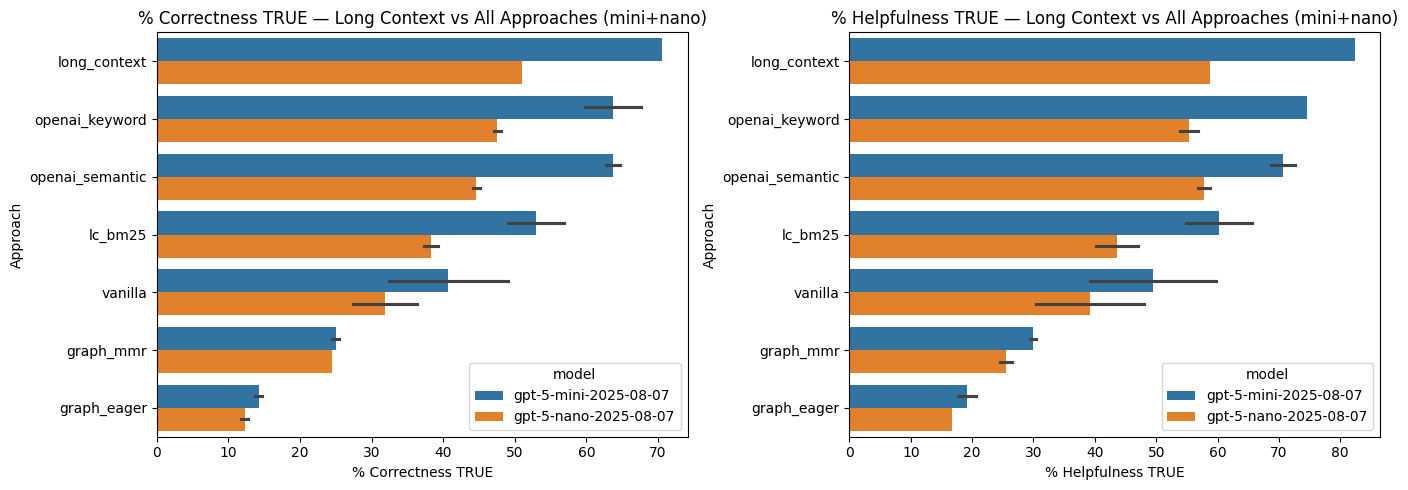

In [76]:
import re
import matplotlib.pyplot as plt
import seaborn as sns

bool_cols = ["judge_answer_correctness_vs_ref", "judge_answer_helpfulness"]
for col in bool_cols:
    if col in df_combined.columns and df_combined[col].dtype != bool:
        df_combined[col] = df_combined[col].astype(str).str.lower().isin(["true", "1", "yes"])

def parse_seconds(x):
    if pd.isna(x): return None
    m = re.search(r"([\d\.]+)", str(x))
    return float(m.group(1)) if m else None

df_combined["total_elapsed_time_sec"] = df_combined["total_elapsed_time"].apply(parse_seconds)

def compute_price(row):
    tokens = row.get("meta_total_tokens", 0) or 0
    model = str(row.get("model", "")).lower()
    if "nano" in model: rate = 0.40
    elif "mini" in model: rate = 2.00
    elif "opus" in model: rate = 15.00
    else: rate = 1.00
    return (tokens / 1_000_000) * rate

df_combined["price_usd"] = df_combined.apply(compute_price, axis=1)

agg_df = (
    df_combined.groupby(["approach", "model", "top_k"])
    .agg(
        avg_meta_total_tokens=("meta_total_tokens", "mean"),
        avg_price_usd=("price_usd", "mean"),
        avg_latency_sec=("total_elapsed_time_sec", "mean"),
        true_correctness_count=("judge_answer_correctness_vs_ref", "sum"),
        total_correctness_count=("judge_answer_correctness_vs_ref", "count"),
        true_helpfulness_count=("judge_answer_helpfulness", "sum"),
        total_helpfulness_count=("judge_answer_helpfulness", "count"),
    )
    .reset_index()
)
agg_df["pct_correctness_true"] = agg_df["true_correctness_count"] / agg_df["total_correctness_count"] * 100
agg_df["pct_helpfulness_true"] = agg_df["true_helpfulness_count"] / agg_df["total_helpfulness_count"] * 100
agg_df["averaged_score"] = (agg_df["pct_correctness_true"] + agg_df["pct_helpfulness_true"]) / 2

ranked = agg_df.sort_values("averaged_score", ascending=False).reset_index(drop=True)
ranked.index += 1
display(ranked[["approach", "model", "top_k", "avg_latency_sec", "avg_price_usd",
                "pct_correctness_true", "pct_helpfulness_true", "averaged_score"]])

# Bar chart: correctness + helpfulness by approach
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(
    axes,
    ["pct_correctness_true", "pct_helpfulness_true"],
    ["% Correctness TRUE", "% Helpfulness TRUE"],
):
    sns.barplot(
        data=agg_df.sort_values(metric, ascending=False),
        x=metric, y="approach", hue="model", ax=ax,
    )
    ax.set_title(f"{title} — Long Context vs All Approaches (mini+nano)")
    ax.set_xlabel(title)
    ax.set_ylabel("Approach")
plt.tight_layout()
plt.show()